# Hillstrom e-mail experiment: exploration

Working notebook for the checks that shaped the pipeline in `src/`, not a polished summary of it. Everything below runs against the real 64,000-row file (`src/data_loader.load_hillstrom()`), same as every report in `reports/`.

One section here documents an approach that was tried and rejected during the build: reusing `recency`/`history` as the "withheld confounder" for `src/confounded.py`'s DML-failure demonstration didn't actually produce a clean failure. That's worth showing directly, not just stating in `CLAUDE.md`.

In [1]:
import sys
from pathlib import Path

# jupyter kernels don't add the notebook's parent directory to sys.path the way `python file.py`
# does, so `import src` fails without this (same fix app/simulator.py needs, and for the same
# reason: nbconvert's execution cwd doesn't automatically become a sys.path entry either).
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from src.config import ARM_COL, ARMS
from src.data_loader import arm_sizes, load_hillstrom, outcome_rates

df = load_hillstrom()
df.shape

(64000, 13)

## Arm balance and outcome rates

Confirms the numbers `reports/data_dictionary.md` and `reports/02_naive_estimate.md` are built on, computed directly here rather than trusted secondhand.

In [2]:
print(arm_sizes(df))
print()
print(outcome_rates(df))

segment
No E-Mail        21306
Mens E-Mail      21307
Womens E-Mail    21387
Name: count, dtype: int64

                  visit  conversion     spend
segment                                      
No E-Mail      0.106167    0.005726  0.652789
Mens E-Mail    0.182757    0.012531  1.422617
Womens E-Mail  0.151400    0.008837  1.077202


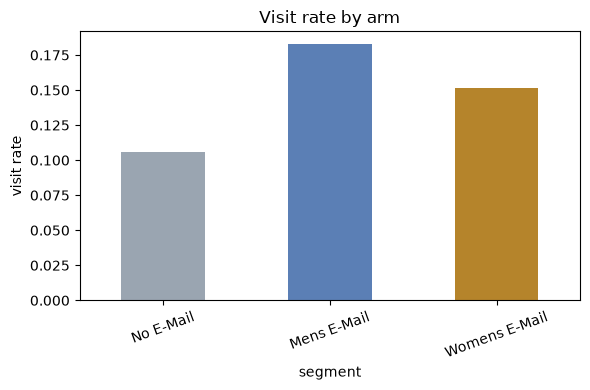

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
outcome_rates(df)["visit"].plot(kind="bar", ax=ax, color=["#9aa5b1", "#5b7fb5", "#b5842b"])
ax.set_ylabel("visit rate")
ax.set_title("Visit rate by arm")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

Mens email visibly outperforms womens email on visit, which is why `src/dml_ate.py` reports per-arm effects rather than only the pooled number, and why `src/policy.py` treats this as a three-action decision.

## `spend` is capped, not naturally maxed out

`reports/data_dictionary.md` states this as a finding; here's the check that established it. If the top spend values were independent purchases, they wouldn't cluster at one exact cent value with a gap below it.

In [4]:
nonzero = df[df["spend"] > 0]["spend"].sort_values(ascending=False)
print("top 15 spend values:", nonzero.head(15).tolist())
print("count exactly at 499.00:", (df["spend"] == 499.0).sum())
print("next-highest value:", nonzero[nonzero < 499.0].max())

top 15 spend values: [499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 482.31, 462.78, 444.92]
count exactly at 499.00: 12
next-highest value: 482.31


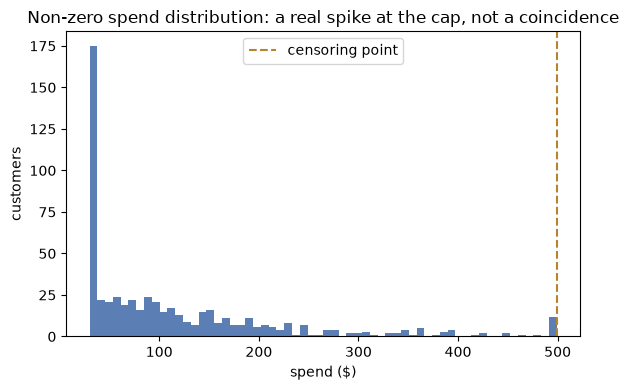

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nonzero, bins=60, color="#5b7fb5")
ax.axvline(499.0, color="#b5842b", linestyle="--", label="censoring point")
ax.set_xlabel("spend ($)")
ax.set_ylabel("customers")
ax.set_title("Non-zero spend distribution: a real spike at the cap, not a coincidence")
ax.legend()
fig.tight_layout()

## Tried and rejected: reusing `recency`/`history` for the withheld-confounder demonstration

`src/confounded.py`'s variant 2 needs a confounder that genuinely breaks every estimator when withheld, to show DML doesn't magically fix unobserved confounding. The first thing tried was the same `recency`/`history` selection mechanism as variant 1, just withholding one of the two columns from the estimator's `X` (instead of introducing a new confounder). It didn't work as a clean failure demonstration, and here's why, reproduced directly rather than just described.

In [6]:
from src.config import RANDOM_SEED
from src.confounded import dml_estimate, make_confounded_sample, naive_diff

benchmark = 0.0601  # pooled DML ATE on the real, unconfounded RCT (reports/05_dml_ate.md)

sub = make_confounded_sample(
    df, ["recency", "history"], {"recency": -1, "history": 1}, strength=1.2, seed=RANDOM_SEED
)
print("naive diff on the confounded sample:", naive_diff(sub, "visit"), "vs benchmark", benchmark)

# withhold only "history" — recency, which selection also depends on, stays observed
attempt = dml_estimate(sub, "visit", drop_cols=["history"])
print("DML with history withheld, recency still observed:", attempt)
print("benchmark inside this CI?", attempt["ci_low"] <= benchmark <= attempt["ci_high"])

C:\Users\aakas\Documents\Projects\Github Projects\Causal ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


naive diff on the confounded sample: 0.10029009027449032 vs benchmark 0.0601


DML with history withheld, recency still observed: {'ate': 0.06836998291463256, 'ci_low': 0.05850643727775519, 'ci_high': 0.07823352855150993}
benchmark inside this CI? True


The naive estimate is badly biased (as expected), but DML's confidence interval **still contains the true benchmark** even with `history` withheld — `recency` alone, still observed and correlated with the same selection mechanism, is enough for the estimator to partially correct itself. That's not the clean failure the confounding benchmark needed to make its point honestly.

The fix, used in the actual `src/confounded.py`: confound on `newbie` instead, a covariate close to orthogonal to the others with a real, standalone effect on `visit`, and withhold it entirely. That produces a genuine, unambiguous failure (`reports/06_confounding_benchmark.md`), reproduced below.

In [7]:
sub2 = make_confounded_sample(df, ["newbie"], {"newbie": -1}, strength=1.5, seed=RANDOM_SEED)
newbie_withheld = dml_estimate(sub2, "visit", drop_cols=["newbie"])
print("DML with newbie withheld entirely:", newbie_withheld)
print(
    "benchmark inside this CI?",
    newbie_withheld["ci_low"] <= benchmark <= newbie_withheld["ci_high"],
)

DML with newbie withheld entirely: {'ate': 0.09490164194835683, 'ci_low': 0.08718395326648076, 'ci_high': 0.1026193306302329}
benchmark inside this CI? False


## Covariate distributions by arm

The formal balance check is in `reports/02_naive_estimate.md` (standardised differences, max 0.0088); this is what that balance actually looks like visually.

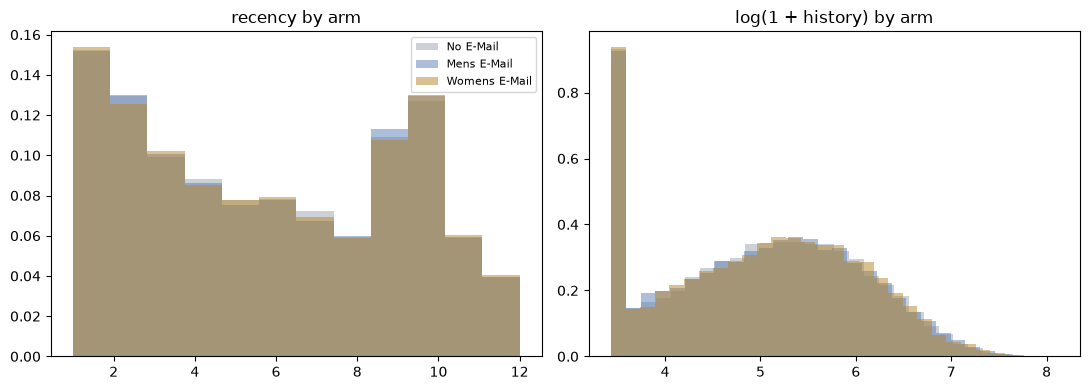

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm, color in zip(ARMS, ["#9aa5b1", "#5b7fb5", "#b5842b"], strict=True):
    sub_arm = df[df[ARM_COL] == arm]
    axes[0].hist(sub_arm["recency"], bins=12, alpha=0.5, label=arm, color=color, density=True)
    axes[1].hist(
        np.log1p(sub_arm["history"]), bins=30, alpha=0.5, label=arm, color=color, density=True
    )
axes[0].set_title("recency by arm")
axes[1].set_title("log(1 + history) by arm")
axes[0].legend(fontsize=8)
fig.tight_layout()

Near-identical distributions across arms, as a real randomised experiment should show. This is the visual version of the standardised-difference table; the pipeline in `src/` is what actually gets reported on and tested, this notebook is where that got checked by eye first.